# Lab 8 – Visualization of Text Data
<hr style="border: 2px solid black;">

**Objectives:**
1. Learn to preprocess and clean text data
2. Build **Word Clouds** (positive vs negative reviews)
3. Perform **Sentiment Analysis** with TextBlob and visualize results
4. Visualize **Named Entity Recognition** (NER) with spaCy and displacy
5. Explore **TF-IDF** and bar charts of top keywords per category
6. Build a **Frequency Distribution** plot of the most common words

<hr style="border: 2px solid black;">

## 1. Installation & Imports (Google Colab)

In [1]:
# ── Install required libraries (run once in Google Colab) ──────────────────
import subprocess, sys

packages = ["wordcloud", "textblob", "spacy", "matplotlib", "pandas",
            "numpy", "scikit-learn", "nltk", "seaborn"]

subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages)

# Download spaCy English model
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Download TextBlob corpora
subprocess.run([sys.executable, "-m", "textblob.download_corpora"], capture_output=True)

print("✓ All dependencies installed and ready!")

✓ All dependencies installed and ready!


In [2]:
# ── Core imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

import spacy
from spacy import displacy

print("✓ Imports successful!")

✓ Imports successful!


## 2. Dataset – Product Reviews

We embed a sample product-review dataset directly. No file upload required.

In [3]:
# ── Embedded reviews dataset ───────────────────────────────────────────────
reviews_data = [
    # Positive
    ("This product is absolutely amazing! I love it so much.",                     "positive"),
    ("The features are fantastic and it works perfectly.",                          "positive"),
    ("I am extremely happy with this purchase. Highly recommended!",               "positive"),
    ("Good value for the price. I am satisfied with the quality.",                 "positive"),
    ("Really impressed with the quality and performance!",                          "positive"),
    ("So glad I bought this! It has made my life easier.",                         "positive"),
    ("A solid product that does exactly what it says.",                            "positive"),
    ("Exceeded my expectations in every way. Five stars!",                         "positive"),
    ("The build quality is outstanding and the design is beautiful.",              "positive"),
    ("Fast shipping, great packaging, and an excellent product overall.",           "positive"),
    # Negative
    ("What a terrible experience. The product broke after just one use.",          "negative"),
    ("This is the worst item I have ever bought. Complete waste of money.",        "negative"),
    ("I was so disappointed. It did not meet my expectations at all.",             "negative"),
    ("The customer service was awful and unhelpful.",                              "negative"),
    ("Avoid this product at all costs! Seriously flawed design.",                  "negative"),
    ("The setup was confusing and the instructions were completely unclear.",       "negative"),
    ("Broke within a week. Very poor quality material.",                           "negative"),
    ("Terrible build quality. I want a refund immediately.",                       "negative"),
    ("Misleading description. The product looks nothing like the photo.",          "negative"),
    ("Extremely frustrated. Returned it the same day I received it.",              "negative"),
    # Neutral
    ("It is okay, but nothing special. Could be better.",                          "neutral"),
    ("Meh, it is alright. Not great, not bad.",                                    "neutral"),
    ("Does what it is supposed to do, nothing more.",                              "neutral"),
    ("Average product for the price. No complaints but no surprises either.",     "neutral"),
    ("It arrived on time and was as described. Fairly standard product.",          "neutral"),
]

df = pd.DataFrame(reviews_data, columns=["review", "sentiment"])

print(f"Dataset shape: {df.shape}")
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())
df.head()

Dataset shape: (25, 2)

Sentiment distribution:
sentiment
positive    10
negative    10
neutral      5
Name: count, dtype: int64


,review,sentiment
0,This product is absolutely amazing! I love it ...,positive
1,The features are fantastic and it works perfec...,positive
2,I am extremely happy with this purchase. Highl...,positive
3,Good value for the price. I am satisfied with ...,positive
4,Really impressed with the quality and performa...,positive


## 3. Text Preprocessing

Tokenization, lowercasing, stopword removal.

In [4]:
STOP_WORDS = set(stopwords.words('english')) | set(STOPWORDS)

def preprocess(text):
    """Lowercase, tokenize, remove stopwords and non-alpha tokens."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    return tokens

df['tokens'] = df['review'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))

print("Sample preprocessed tokens:")
for _, row in df.head(3).iterrows():
    print(f"  [{row.sentiment}]  {row.tokens}")

Sample preprocessed tokens:
  [positive]  ['product', 'absolutely', 'amazing', 'love', 'much']
  [positive]  ['features', 'fantastic', 'works', 'perfectly']
  [positive]  ['extremely', 'happy', 'purchase', 'highly', 'recommended']


## 4. Word Clouds – Positive vs Negative Reviews

Two separate word clouds with different colour schemes.

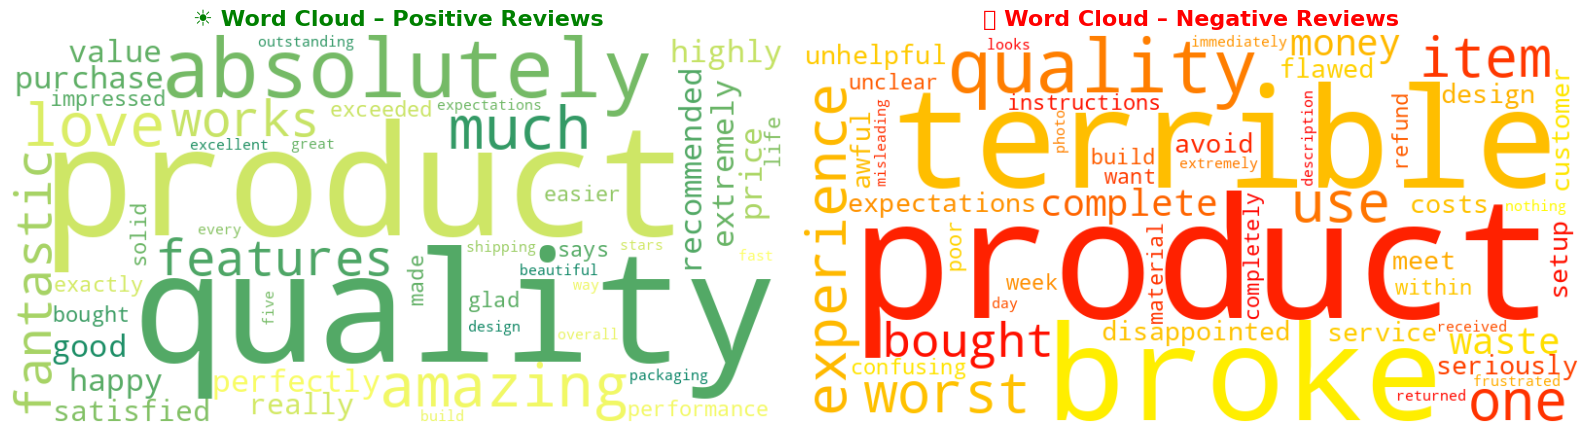

In [5]:
pos_text = ' '.join(df[df['sentiment'] == 'positive']['clean_text'])
neg_text = ' '.join(df[df['sentiment'] == 'negative']['clean_text'])

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='summer', min_font_size=10).generate(pos_text)

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='autumn', min_font_size=10).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☀ Word Cloud – Positive Reviews', fontsize=16, fontweight='bold', color='green')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🔴 Word Cloud – Negative Reviews', fontsize=16, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## 5. Sentiment Analysis with TextBlob

Polarity (–1 to +1) and Subjectivity (0 to 1) scores for each review.

In [6]:
def get_sentiment_scores(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity', 'subjectivity']] = df['review'].apply(
    lambda t: pd.Series(get_sentiment_scores(t))
)

print("Polarity and Subjectivity scores (first 5 rows):")
display(df[['review', 'sentiment', 'polarity', 'subjectivity']].head())

Polarity and Subjectivity scores (first 5 rows):


,review,sentiment,polarity,subjectivity
0,This product is absolutely amazing! I love it ...,positive,0.483333,0.566667
1,The features are fantastic and it works perfec...,positive,0.700000,0.950000
2,I am extremely happy with this purchase. Highl...,positive,0.500000,0.770000
3,Good value for the price. I am satisfied with ...,positive,0.600000,0.800000
4,Really impressed with the quality and performa...,positive,1.000000,1.000000


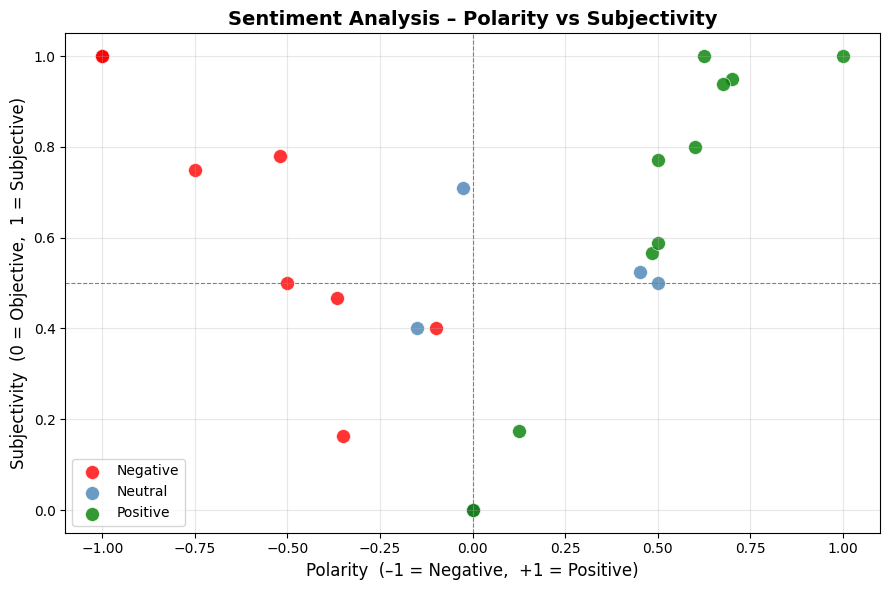

In [7]:
# ── Scatter plot: Polarity vs Subjectivity ─────────────────────────────────
palette = {'positive': 'green', 'negative': 'red', 'neutral': 'steelblue'}

fig, ax = plt.subplots(figsize=(9, 6))
for label, grp in df.groupby('sentiment'):
    ax.scatter(grp['polarity'], grp['subjectivity'],
               label=label.capitalize(), c=palette[label],
               s=100, alpha=0.8, edgecolors='white', linewidths=0.5)

ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Polarity  (–1 = Negative,  +1 = Positive)', fontsize=12)
ax.set_ylabel('Subjectivity  (0 = Objective,  1 = Subjective)', fontsize=12)
ax.set_title('Sentiment Analysis – Polarity vs Subjectivity', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

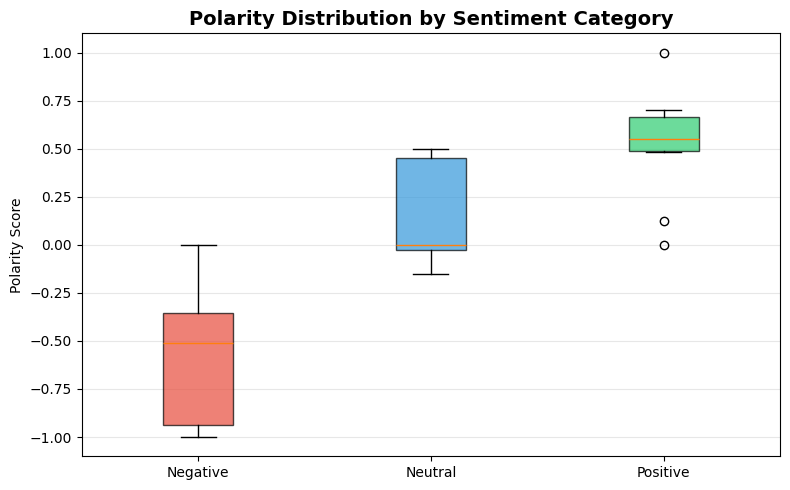

In [8]:
# ── Boxplot: Polarity distribution per sentiment category ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_sorted = df.copy()
order = ['negative', 'neutral', 'positive']
colors = ['#e74c3c', '#3498db', '#2ecc71']

bp = ax.boxplot(
    [df_sorted[df_sorted['sentiment'] == s]['polarity'].values for s in order],
    patch_artist=True,
    labels=[s.capitalize() for s in order]
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Polarity Distribution by Sentiment Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Polarity Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Word Frequency Distribution

Top 20 most frequent words across all reviews (after stopword removal).

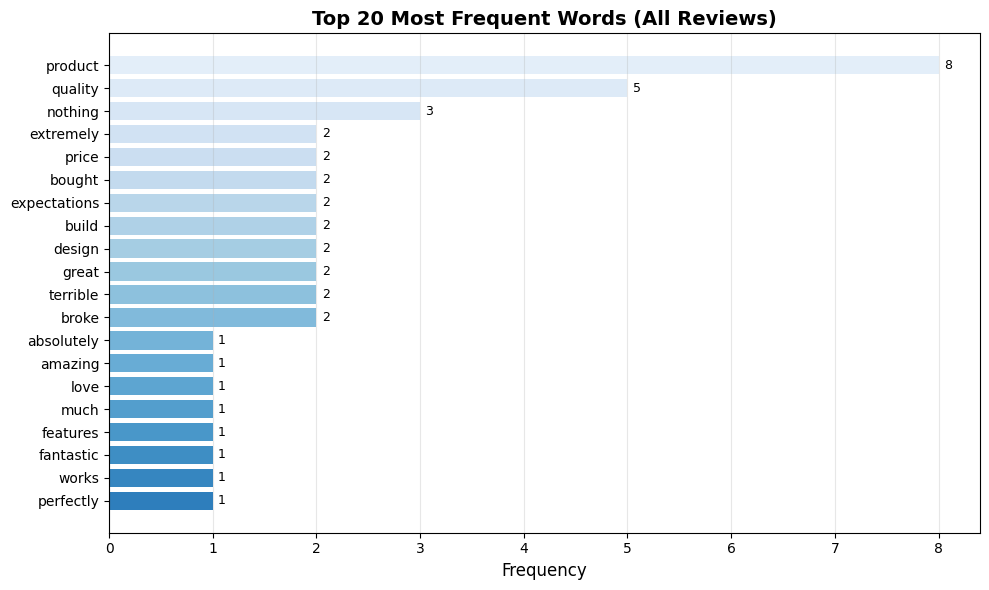

In [9]:
all_tokens = [tok for tokens in df['tokens'] for tok in tokens]
freq = Counter(all_tokens).most_common(20)

words, counts = zip(*freq)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(words[::-1], counts[::-1], color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 20)))
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Most Frequent Words (All Reviews)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, cnt in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. TF-IDF – Top Keywords per Sentiment Category

TF-IDF highlights words that are characteristic of a category (not just frequent).

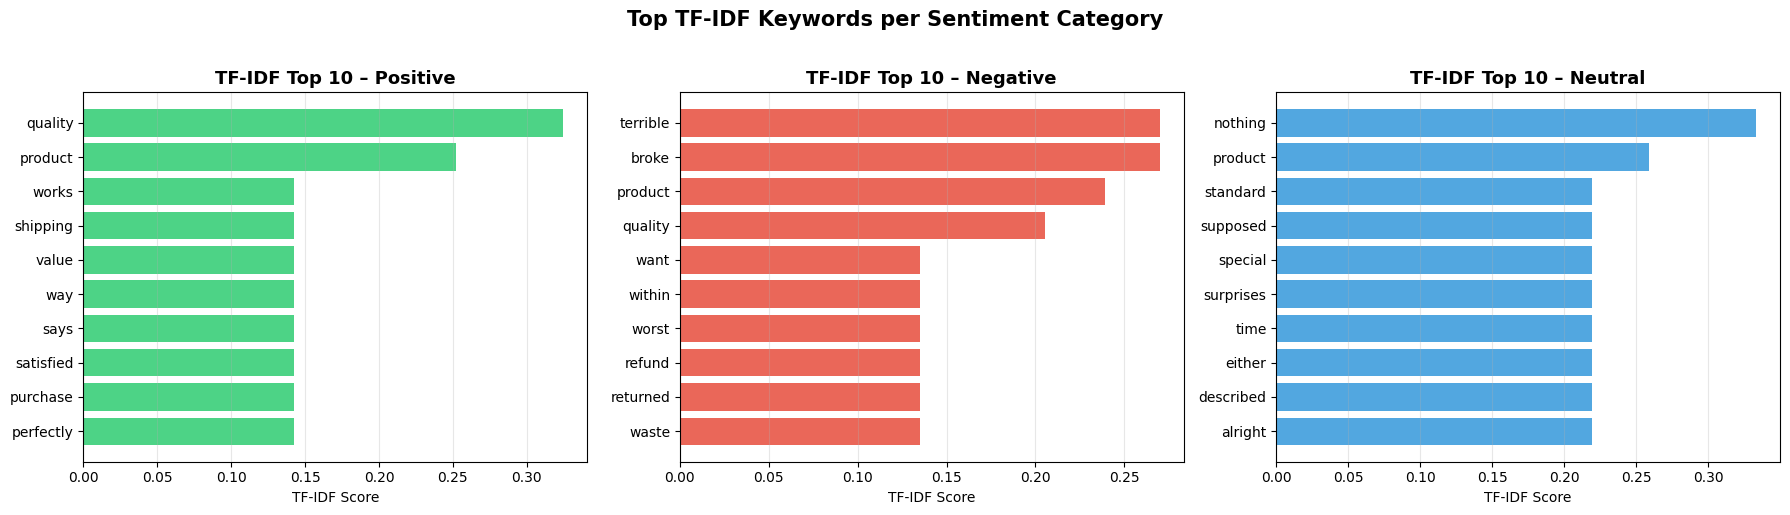

In [10]:
categories = ['positive', 'negative', 'neutral']
category_texts = {
    cat: ' '.join(df[df['sentiment'] == cat]['clean_text'])
    for cat in categories
}

vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = vectorizer.fit_transform(list(category_texts.values()))
feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}

for idx, (cat, ax) in enumerate(zip(categories, axes)):
    scores = tfidf_matrix[idx].toarray()[0]
    top_idx = scores.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    top_scores = [scores[i] for i in top_idx]

    ax.barh(top_words[::-1], top_scores[::-1], color=colors_map[cat], alpha=0.85)
    ax.set_title(f'TF-IDF Top 10 – {cat.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top TF-IDF Keywords per Sentiment Category', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Named Entity Recognition (NER) with spaCy

spaCy identifies people, organisations, locations, monetary values, etc.

In [11]:
nlp = spacy.load("en_core_web_sm")

# ── Example 1: displacy HTML render ────────────────────────────────────────
sample_text = "Apple is looking at buying U.K. startup for $1 billion by January 2025."
doc = nlp(sample_text)

print("Entities found:")
for ent in doc.ents:
    print(f"  '{ent.text}'  →  {ent.label_} ({spacy.explain(ent.label_)})")

# Render inline HTML in Jupyter / Colab
displacy.render(doc, style="ent", jupyter=True)

Entities found:
  'Apple'  →  ORG (Companies, agencies, institutions, etc.)
  'U.K.'  →  GPE (Countries, cities, states)
  '$1 billion'  →  MONEY (Monetary values, including unit)
  'January 2025'  →  DATE (Absolute or relative dates or periods)


In [12]:
# ── Example 2: Dependency parse of a sentence ──────────────────────────────
dep_text = "The quick brown fox jumps over the lazy dog."
doc2 = nlp(dep_text)
displacy.render(doc2, style="dep", jupyter=True,
                options={"compact": True, "color": "steelblue"})

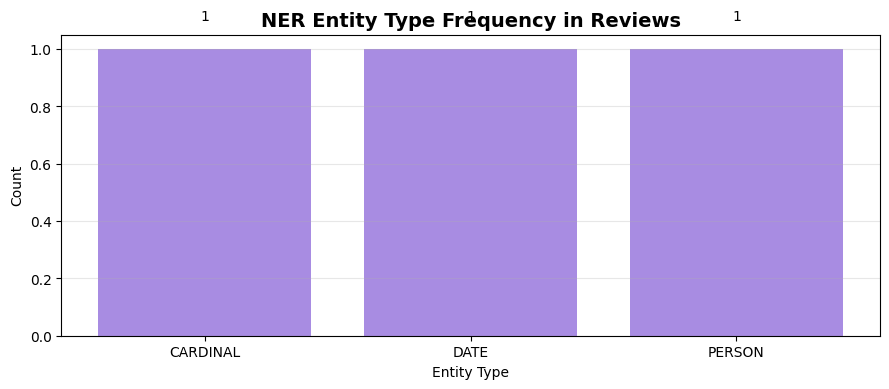

In [13]:
# ── Example 3: NER over all reviews + entity type frequency chart ──────────
entity_counter = Counter()
for text in df['review']:
    doc = nlp(text)
    for ent in doc.ents:
        entity_counter[ent.label_] += 1

if entity_counter:
    labels, counts = zip(*entity_counter.most_common())
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(labels, counts, color='mediumpurple', alpha=0.8)
    ax.set_title('NER Entity Type Frequency in Reviews', fontsize=14, fontweight='bold')
    ax.set_xlabel('Entity Type')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    for i, (l, c) in enumerate(zip(labels, counts)):
        ax.text(i, c + 0.1, str(c), ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No named entities detected in the reviews dataset.")

## 9. Sentiment Distribution Pie Chart

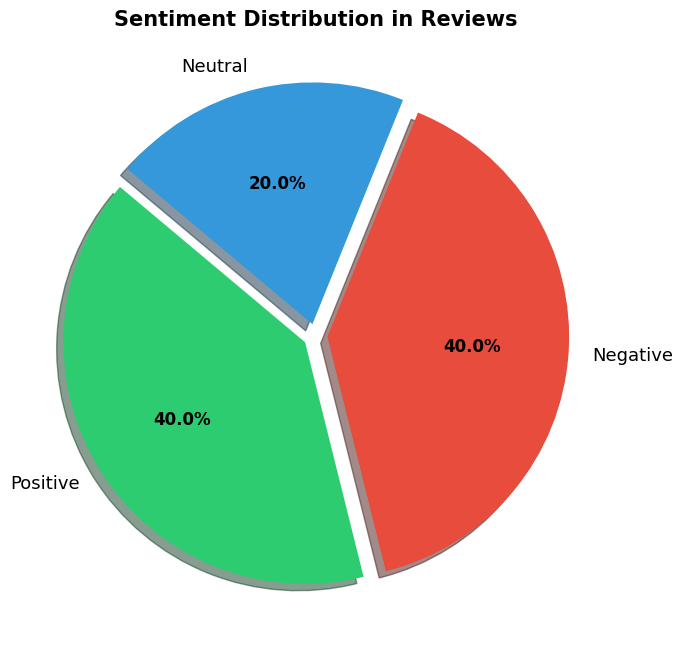

In [14]:
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
explode = [0.05] * len(sentiment_counts)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sentiment_counts,
    labels=[s.capitalize() for s in sentiment_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    shadow=True,
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

ax.set_title('Sentiment Distribution in Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary & Key Takeaways

| Technique | Library | What it shows |
|---|---|---|
| Word Cloud | `wordcloud` | Most frequent words, visual |
| Polarity / Subjectivity | `textblob` | Sentiment score per review |
| Word Frequency | `collections.Counter` | Raw token counts |
| TF-IDF | `scikit-learn` | Distinctive words per category |
| NER | `spacy` | People, orgs, dates, money |
| Dependency Parse | `spacy.displacy` | Grammatical structure |

> **Next steps:** Apply these techniques to a larger corpus (e.g. Twitter data, Amazon reviews) and combine NER + sentiment for richer insights.